# XGBoost 

## 1. Loading Data and Checks

In [21]:
import pandas as pd

train_path = r"E:\INCOIS_Internhip\Data\train_scaled.parquet"
train_df = pd.read_parquet(train_path)

val_path = r"E:\INCOIS_Internhip\Data\val_scaled.parquet"
val_df = pd.read_parquet(val_path)

test_path = r"E:\INCOIS_Internhip\Data\test_scaled.parquet"
test_df = pd.read_parquet(test_path)

train_df.head()

,WMOID,CYCLE,DATES,LON,LAT,Depth(m),TEMP(degC),PSAL(psu),time_days,doy,doy_sin,doy_cos,profile_id,PSAL_scaled
0,1900185,79,2005-12-21 08:34:00,-0.400299,-1.503385,-1.268884,2.362755,33.384998,-3.483251,355,-0.075933,1.46713,0,-5.411375
1,1900185,79,2005-12-21 08:34:00,-0.400299,-1.503385,-1.258722,2.383696,33.908001,-3.483251,355,-0.075933,1.46713,0,-3.784688
2,1900185,79,2005-12-21 08:34:00,-0.400299,-1.503385,-1.247963,2.377734,34.282001,-3.483251,355,-0.075933,1.46713,0,-2.621439
3,1900185,79,2005-12-21 08:34:00,-0.400299,-1.503385,-1.219471,2.409000,35.721001,-3.483251,355,-0.075933,1.46713,0,1.854260
4,1900185,79,2005-12-21 08:34:00,-0.400299,-1.503385,-1.199548,2.412635,36.176998,-3.483251,355,-0.075933,1.46713,0,3.272542


In [22]:
# Checks
print(train_df[['LAT','LON','Depth(m)','TEMP(degC)','time_days']].mean()) # ~0
print(train_df[['LAT','LON','Depth(m)','TEMP(degC)','time_days']].std()) # ~1

# Checks all columns
print("Columns:", train_df.columns.tolist())

#Checks datatypes
train_df.dtypes

LAT          -1.907087e-17
LON           2.097796e-15
Depth(m)     -7.628349e-17
TEMP(degC)    2.860631e-17
time_days    -4.958427e-16
dtype: float64
LAT           1.000001
LON           1.000001
Depth(m)      1.000001
TEMP(degC)    1.000001
time_days     1.000001
dtype: float64
Columns: ['WMOID', 'CYCLE', 'DATES', 'LON', 'LAT', 'Depth(m)', 'TEMP(degC)', 'PSAL(psu)', 'time_days', 'doy', 'doy_sin', 'doy_cos', 'profile_id', 'PSAL_scaled']


WMOID                   int64
CYCLE                   int64
DATES          datetime64[ns]
LON                   float64
LAT                   float64
Depth(m)              float64
TEMP(degC)            float64
PSAL(psu)             float64
time_days             float64
doy                     int32
doy_sin               float64
doy_cos               float64
profile_id              int64
PSAL_scaled           float64
dtype: object

## 2. Selecting Features and Target

In [23]:
features = ['TEMP(degC)', 'Depth(m)', 'LAT', 'LON', 'time_days']
target = 'PSAL(psu)'

X_train = train_df[features]
y_train = train_df[target]

X_val = val_df[features]
y_val = val_df[target]

X_test = test_df[features]
y_test = test_df[target]

# 3. Training the Model

In [24]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the model/XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=100,  # train for all 100 trees
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit on training data (without early stopping)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Finding the best Iteration

In [25]:
best_iter = 0
best_rmse = float('inf')

for i in range(1, xgb_model.n_estimators + 1):
    y_val_pred = xgb_model.predict(
        X_val,
        iteration_range=(0, i)
    )
    
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_iter = i

print(f"Best iteration: {best_iter}")
print(f"Best validation RMSE: {best_rmse}")

Best iteration: 100
Best validation RMSE: 0.14904649893295333


In [26]:
# Re-setting n_estimators to 200 since, we didn't reach overfititing limit
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the model/XGBoost Regressor
xgb_model = XGBRegressor(
    n_estimators=800,  # train for all 100 trees
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Fit on training data (without early stopping)
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


### Training using the Best Iteration

In [27]:
best_iter = 0
best_rmse = float('inf')

for i in range(1, xgb_model.n_estimators + 1):
    y_val_pred = xgb_model.predict(
        X_val,
        iteration_range=(0, i)
    )
    
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_iter = i

print(f"Best iteration: {best_iter}")
print(f"Best validation RMSE: {best_rmse}")

Best iteration: 691
Best validation RMSE: 0.13418994905464113


In [28]:
final_model = XGBRegressor(
    n_estimators = best_iter,  # locking the best number of trees
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42 # fixing randomness in subsample=0.8, colsample_bytree=0.8

)

final_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 4. Evaluating using Test Set

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.3f}, RMSE: {rmse:.3f}, R²: {r2:.3f}")

MAE: 0.044, RMSE: 0.128, R²: 0.847


## 5. Feature Importance

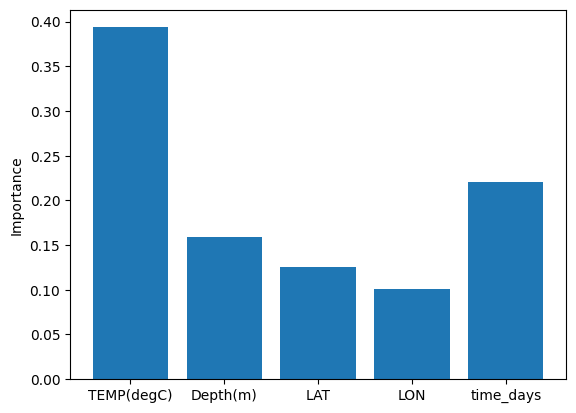

In [30]:
import matplotlib.pyplot as plt

importances = xgb_model.feature_importances_
plt.bar(features, importances)
plt.ylabel("Importance")
plt.show()

### RMSE vs Number of Trees (Convergence Plot)

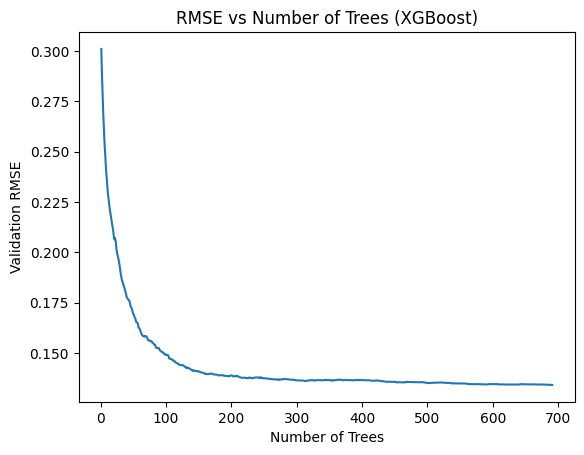

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

rmse_vals = []

for i in range(1, final_model.n_estimators + 1):
    y_val_pred = final_model.predict(
        X_val,
        iteration_range=(0, i)
    )
    rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    rmse_vals.append(rmse)

plt.figure()
plt.plot(range(1, final_model.n_estimators + 1), rmse_vals)
plt.xlabel("Number of Trees")
plt.ylabel("Validation RMSE")
plt.title("RMSE vs Number of Trees (XGBoost)")
plt.show()

## 6. Plots

(a) Observed vs Predicted Salinity

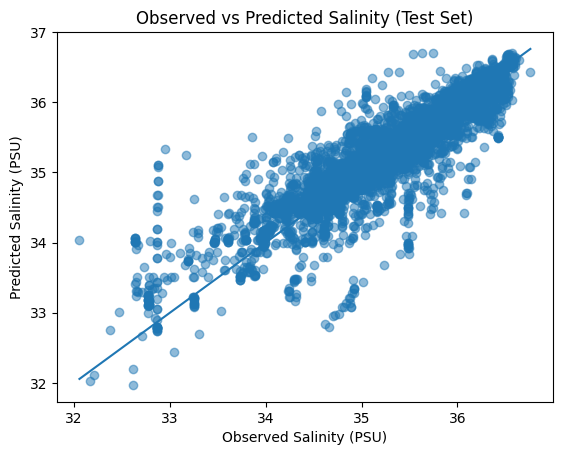

In [32]:
import matplotlib.pyplot as plt

# Predictions on test set
y_test_pred = final_model.predict(X_test)

plt.figure()
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)
plt.xlabel("Observed Salinity (PSU)")
plt.ylabel("Predicted Salinity (PSU)")
plt.title("Observed vs Predicted Salinity (Test Set)")
plt.show()

(b) Residuals vs Depth

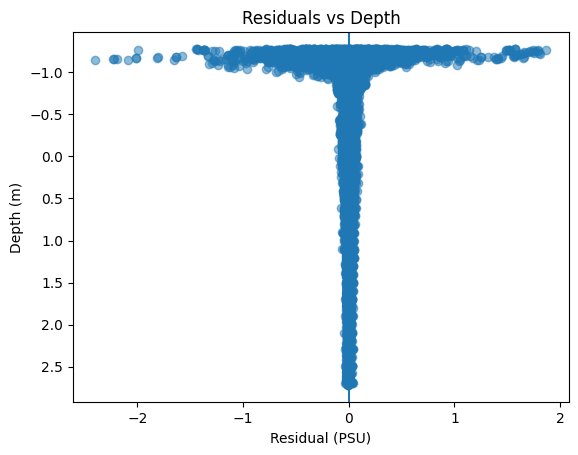

In [33]:
residuals = y_test - final_model.predict(X_test)

plt.scatter(residuals, X_test["Depth(m)"], alpha=0.5)
plt.axvline(0)
plt.xlabel("Residual (PSU)")
plt.ylabel("Depth (m)")
plt.gca().invert_yaxis()
plt.title("Residuals vs Depth")
plt.show()

(c) Random Profile Plot - Predicted and Actual Salinity

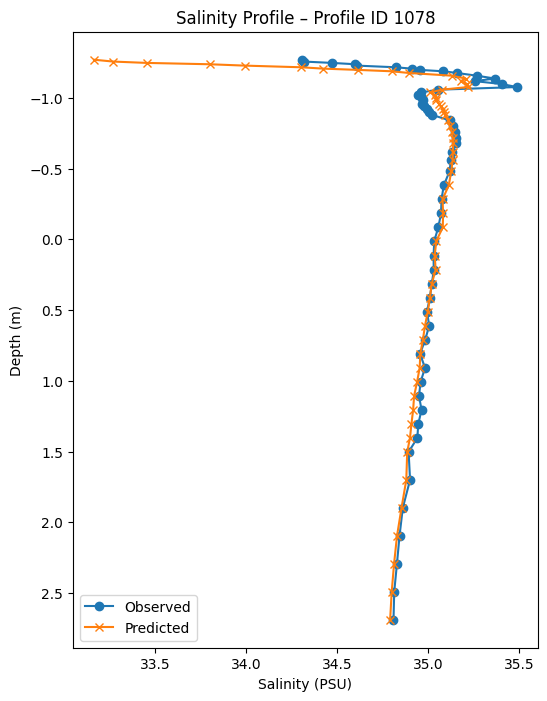

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Pick 1 random profile from test set
random_profile = np.random.choice(test_df['profile_id'].unique())

# Filter test set for this profile
profile_mask = test_df['profile_id'] == random_profile
X_profile = X_test.loc[profile_mask]
y_profile = y_test.loc[profile_mask]

# Predict salinity for this profile
y_pred_profile = final_model.predict(X_profile)

# Sort by depth
depths = test_df.loc[profile_mask, 'Depth(m)'].values
sorted_idx = np.argsort(depths)

depths_sorted = depths[sorted_idx]
y_actual_sorted = y_profile.values[sorted_idx]
y_pred_sorted = y_pred_profile[sorted_idx]

# Plot salinity profiles
plt.figure(figsize=(6, 8))
plt.plot(y_actual_sorted, depths_sorted, label='Observed', marker='o')
plt.plot(y_pred_sorted, depths_sorted, label='Predicted', marker='x')
plt.gca().invert_yaxis()  # oceanographic convention
plt.xlabel('Salinity (PSU)')
plt.ylabel('Depth (m)')
plt.title(f'Salinity Profile – Profile ID {random_profile}')
plt.legend()
plt.show()

## 7. Saving the Model

In [35]:
import joblib
joblib.dump(xgb_model, "xgb_salinity_model.pkl")

['xgb_salinity_model.pkl']

# MODEL

In [36]:
import pandas as pd
import joblib

# Load trained model
loaded_model = joblib.load("xgb_salinity_model.pkl")

# User input
lat = float(input("Latitude: "))
lon = float(input("Longitude: "))
depth = float(input("Depth (m): "))
temp = float(input("Temperature (°C): "))
time_days = float(input("Time (days since 2005-01-01): "))

# Create DataFrame
new_X = pd.DataFrame({
    "LAT": [lat],
    "LON": [lon],
    "Depth(m)": [depth],
    "TEMP(degC)": [temp],
    "time_days": [time_days]
})

# Reorder columns exactly as training
new_X = new_X[['TEMP(degC)', 'Depth(m)', 'LAT', 'LON', 'time_days']]

# Predict
predicted_salinity = loaded_model.predict(new_X)
print(f"Predicted Salinity: {predicted_salinity[0]:.3f} PSU")

KeyboardInterrupt: Interrupted by user